In [1]:
import numpy as np
import matplotlib.pyplot as plt

### questiion 1.
- a)

In [2]:
# list of integers
n = 10
x = [np.random.randint(1, 51) for i in range(n)]

# sum of even integer
sums = 0
for i in range(n):
    if x[i]%2 == 0:
        sums += x[i]

print(x)
print(sums)        

[47, 20, 38, 37, 9, 30, 31, 18, 43, 40]
146


- b)

In [3]:
x = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
y = [1.0, 3.0, 7.0, 13.0, 21.0, 31.0]

In [4]:
def linear_interpolation(x, y, x_given):
    n = len(x)
    for i in range(n):
        if x[i] < x_given < x[i+1]:
            y_given = y[i] + (((y[i+1]-y[i])/(x[i+1]-x[i]))*(x_given-x[i]))
    return y_given        

In [5]:
print(linear_interpolation(x, y, 2.5))
print(linear_interpolation(x, y, 1.9))

10.0
6.6


In [6]:
def lagrange_interpolation(x, y, m, x_given):
    n = len(x)
    l = np.ones(m)
    y_given = 0
    for i in range(m):
        for j in range(m):
            if j!=i : 
                l[i] *= (x_given-x[j])/(x[i]-x[j])
        y_given += y[i]*l[i]
    return y_given        
                
        
    

In [15]:
print(lagrange_interpolation(x, y, 6, 2.5))
print(lagrange_interpolation(x, y, 6, 1.9))

9.75
6.509999999999999


- c)

In [16]:
# fibonacci series
def fibonacci(n):
    a = [0, 1]
    for i in range(n-2):
        a.append(a[i]+a[i+1])
    return a    

For large n the golden ratio approaches to =  1.618034055727554


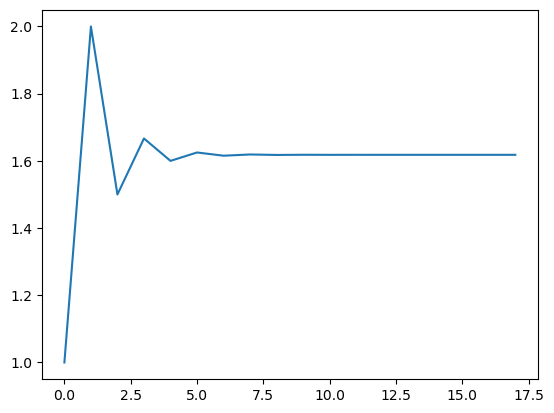

In [17]:
n = 20
a = fibonacci(n)
golden_ratio = []
for j in range(2, n):
    F = a[j]/a[j-1]
    golden_ratio.append(F)
print('For large n the golden ratio approaches to = ', golden_ratio[-1])    
plt.plot(golden_ratio)    

- d)

In [20]:
x = np.array([0.0, 0.2, 0.7, 1.5, 1.9, 2.6, 3.1, 3.9, 4.0], dtype = float)
y = np.array([1.0, 1.4, 2.4, 4.0, 4.8, 6.2, 7.2, 8.8, 9.0], dtype = float)

y_given = np.sum(np.diff(x)*(y[:-1]+y[1:])/2)
print(y_given)  

20.0


In [21]:
"""This is Trapazoidal integration. It is a linear function."""

'This is Trapazoidal integration. It is a linear function.'

### Question 2. 

In [40]:
def f(x):
    return x**4 - 4*x**2 + x + 1
    

Peak indices: [25, 72]

Peak at bin 25: Count = 35106.0
Range = (-1.4961155398987311, -1.436240469975984)
Center = -1.4661780049373576


Peak at bin 72: Count = 29775.0
Range = (1.3180127464703788, 1.3778878163931263)
Center = 1.3479502814317526




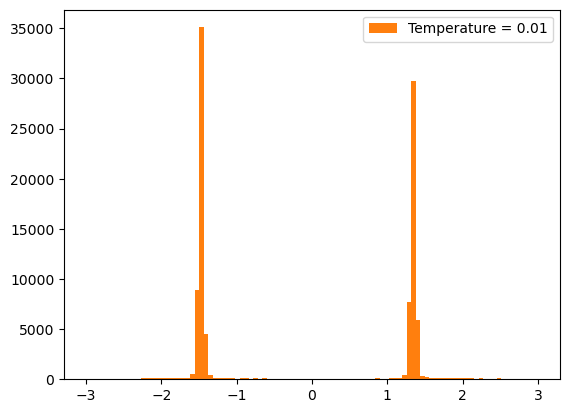

Peak indices: [24, 72]

Peak at bin 24: Count = 5253.0
Range = (-1.5564190205334407, -1.4965466868530704)
Center = -1.5264828536932555


Peak at bin 72: Count = 4126.0
Range = (1.3174529961243282, 1.377325329804699)
Center = 1.3473891629645136




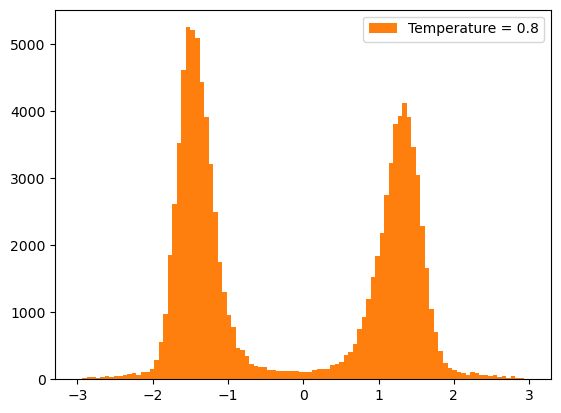

In [41]:
n = 100000
b = 1000
temp = np.array([0.01,0.8])
# step 1
for T in temp:
    x_traj = []
    # step 2
    for j in range(b):
        x_now = np.random.uniform(-3,3)
        for i in range(int(n/b)):
            x_trail = x_now + 0.4*(2*np.random.rand()-1)
            # step 3
            if f(x_trail) < f(x_now):
                x_now = x_trail
            else:
                p = np.exp(-(f(x_trail)-f(x_now))/T)
                if np.random.rand() < p:
                    x_now = x_trail
            x_traj.append(x_now)
            x_traj[5000:]

    counts, bin_edges, _ = plt.hist(x_traj, bins=100)
    peaks = []
    for i in range(1, len(counts)-1):
        if counts[i]>(n/200):
            if counts[i] > counts[i-1] and counts[i] > counts[i+1]:
                peaks.append(i)
    print(f"Peak indices: {peaks}\n")
    for i in peaks:
        center = 0.5 * (bin_edges[i] + bin_edges[i+1])
        print(f"Peak at bin {i}: Count = {counts[i]}\n"
            f"Range = ({bin_edges[i]}, {bin_edges[i+1]})\n"
            f"Center = {center}\n\n")
    #plt.plot(x_traj)
    plt.hist(x_traj, bins = 100, label = f'Temperature = {T}')
    plt.legend()
    plt.show()

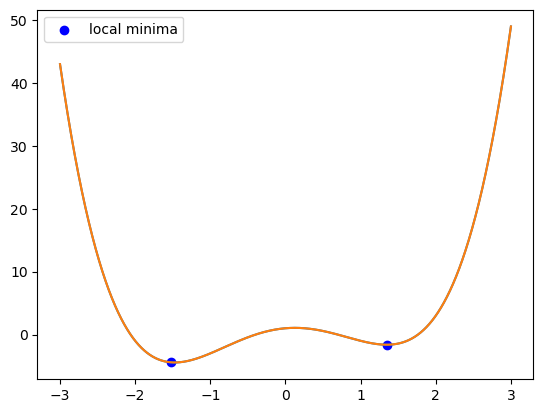

In [42]:
x = np.linspace(-3, 3, n)
plt.plot(x,f(x)) 
centers = [0.5*(bin_edges[i] + bin_edges[i+1]) for i in peaks]
plt.plot(x, f(x))
plt.scatter(centers, [f(c) for c in centers], color='b', label='local minima')
plt.legend()
plt.show()

In [23]:
def f1(x):
    return x**4 - 10*x**2 + 5*x + 3*np.sin(4*x) + 2*np.sin(9*x)

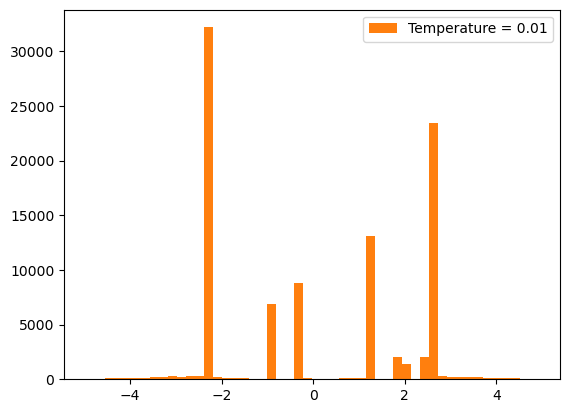

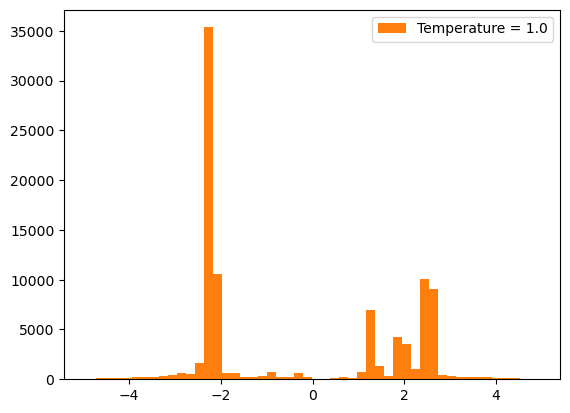

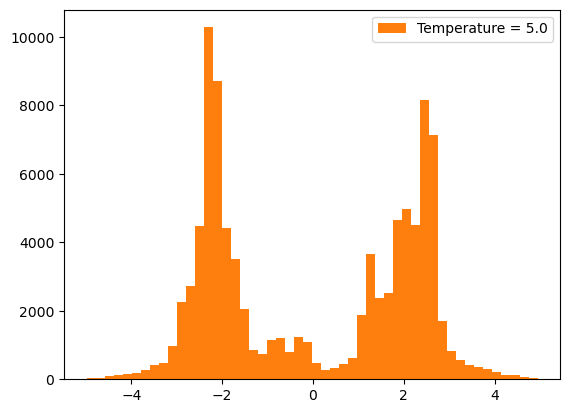

In [31]:
n = 100000
b = 200
temp = np.array([0.01,1.0,5.0])
peaks = []
# step 1
for T in temp:
    x_traj = []
    # step 2
    for j in range(b):
        x_now = np.random.uniform(-5,5)
        for i in range(int(n/b)):
            
            x_trail = x_now + 0.1*(2*np.random.rand()-1)
            # step 3
            if f1(x_trail) < f1(x_now):
                x_now = x_trail
                
            else:
                p = np.exp(-(f1(x_trail)-f1(x_now))/T)
                if np.random.rand() < p:
                    x_now = x_trail
            x_traj.append(x_now)
    x_traj = x_traj[5000:]

    
    counts, bin_edges, _ = plt.hist(x_traj, bins=100)
    
    for i in range(1, len(counts)-1):
        if counts[i]>(n/200):
            if counts[i] > counts[i-1] and counts[i] > counts[i+1]:
                peaks.append(i)
    peaks = list(set(peaks))            
    #print(f"Peak indices: {peaks}\n")
    plt.hist(x_traj, bins = 50,label = f'Temperature = {T}')
    plt.legend()
    plt.show()

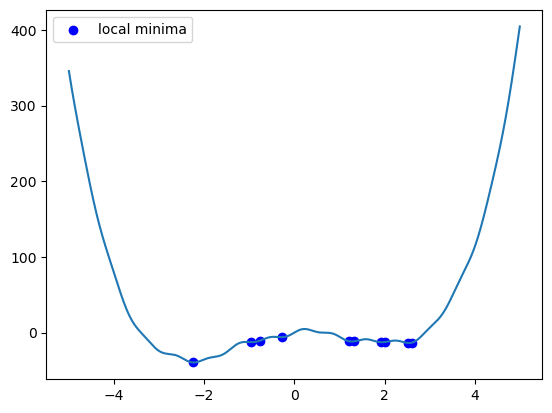

In [32]:
x = np.linspace(-5, 5, n)
plt.plot(x,f1(x)) 
centers = [0.5*(bin_edges[i] + bin_edges[i+1]) for i in peaks]
plt.scatter(centers, [f1(c) for c in centers], color='b', label='local minima')
plt.legend()
plt.show()   